# step:1 Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# step:2 Load Dataset

In [ ]:
df = pd.read_csv("diamonds.csv")

# step:3 EDA

In [ ]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.shape

(53940, 11)

In [ ]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [ ]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# step:4 Train-Test-Split

In [ ]:
X = df.drop("price",axis=1)
y = df["price"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# step:5 Data visualizations

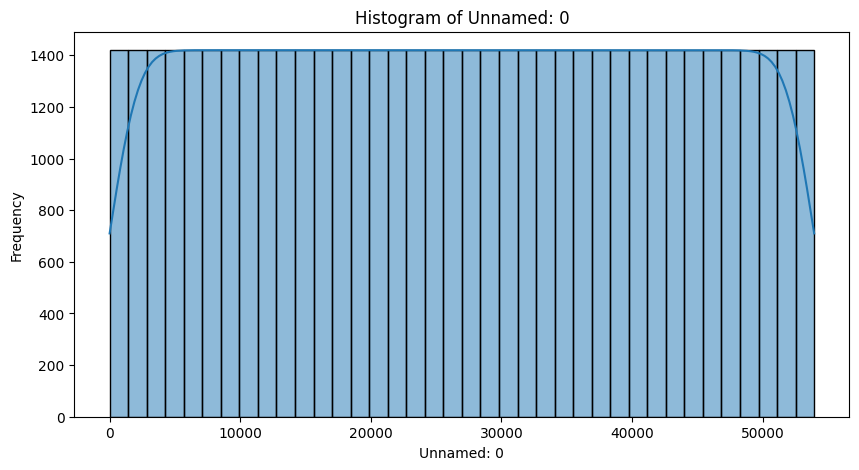

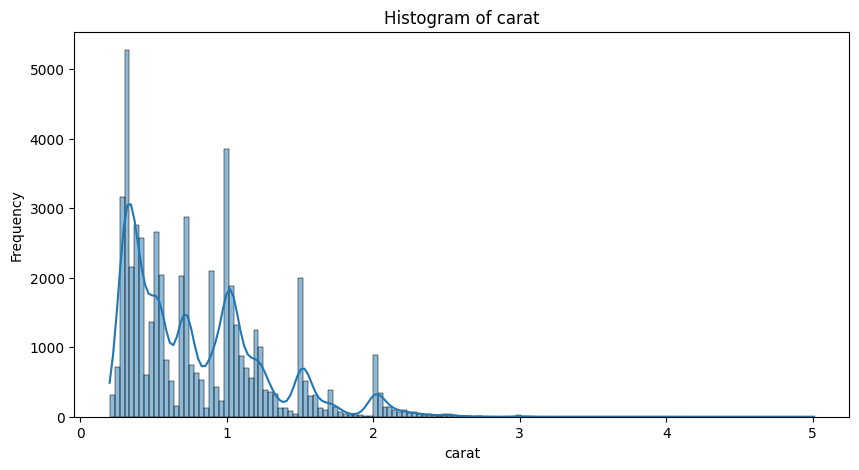

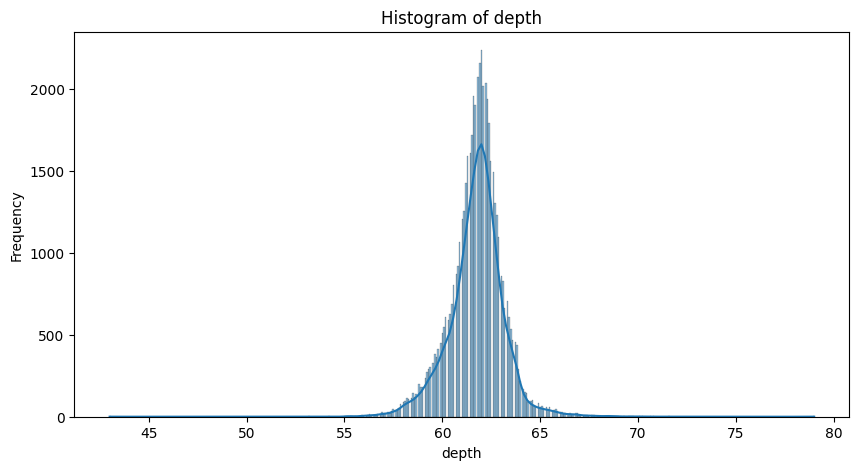

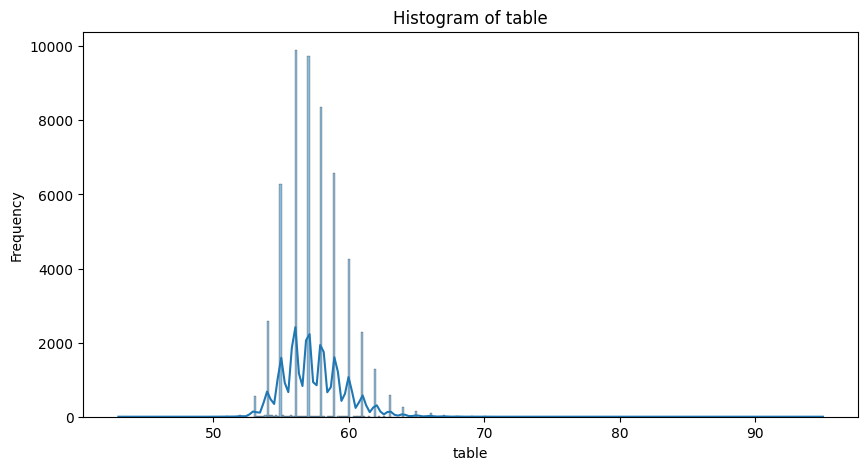

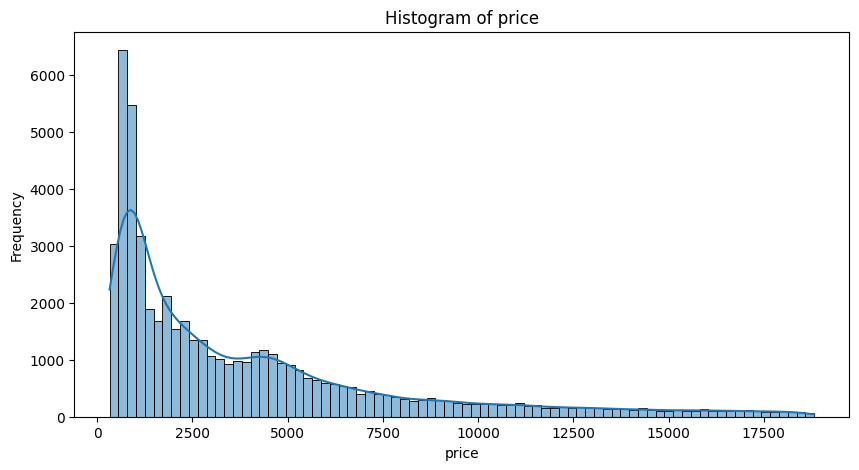

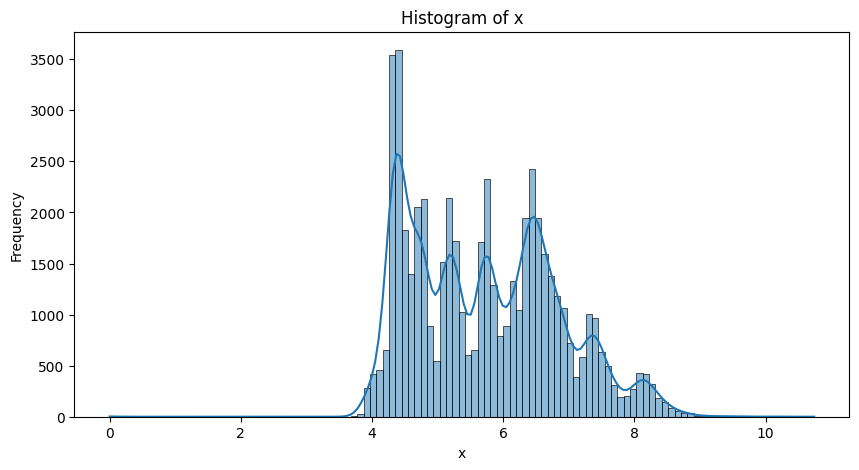

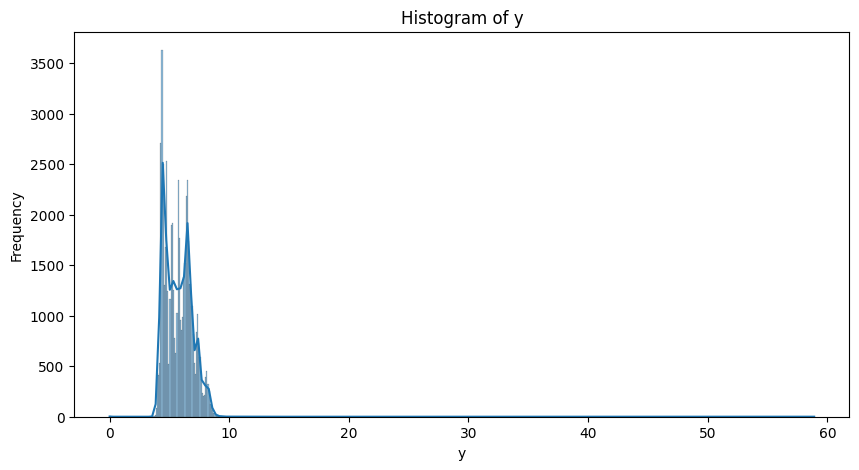

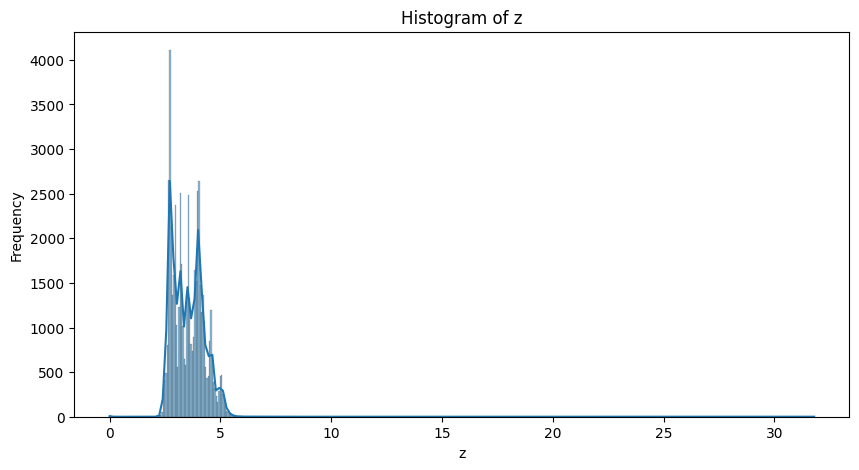

In [ ]:
num_cols = df.select_dtypes(exclude="object").columns
for col in num_cols:
  plt.figure(figsize=(10,5))
  sns.histplot(df[col],kde=True)
  plt.title(f"Histogram of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.show()

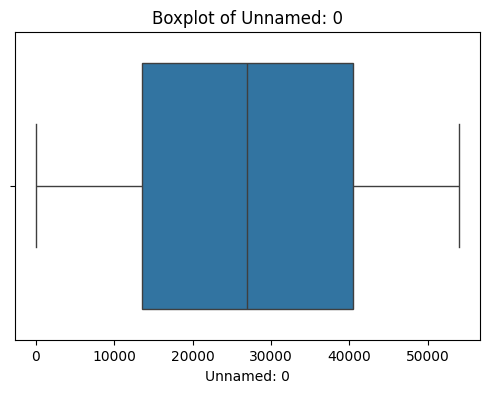

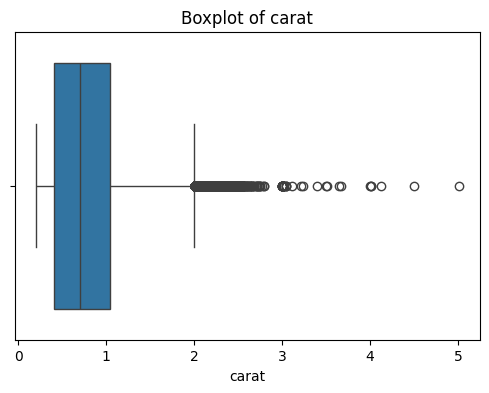

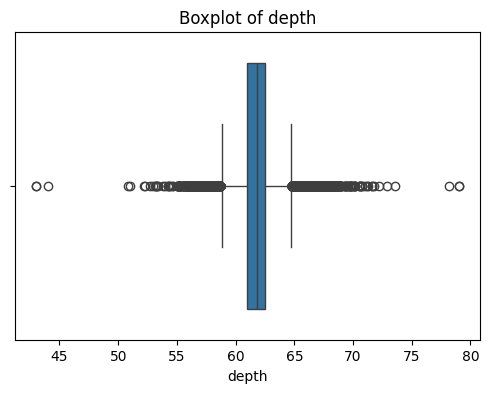

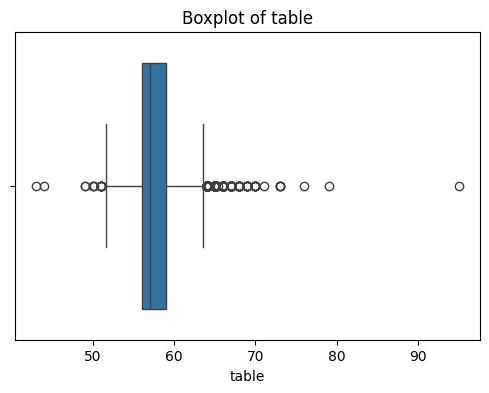

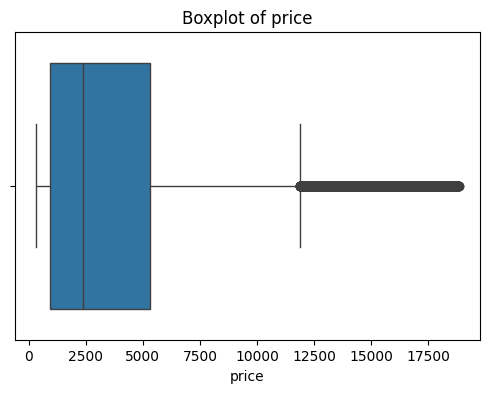

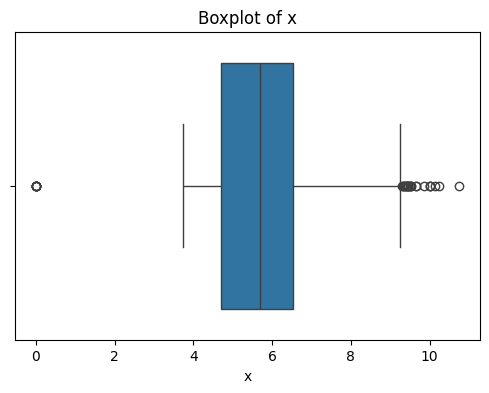

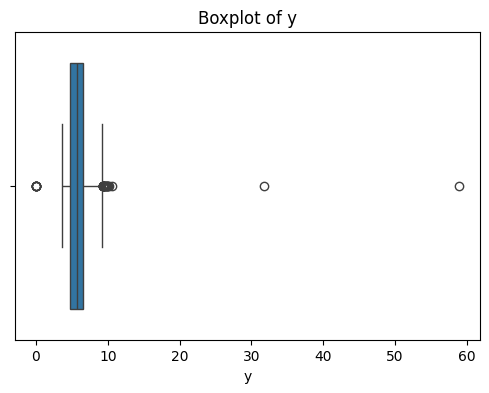

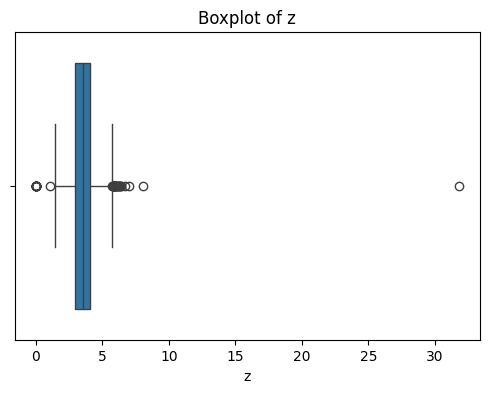

In [ ]:
for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")
  plt.show()

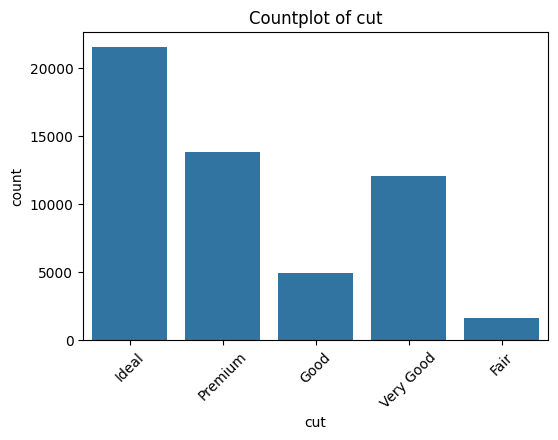

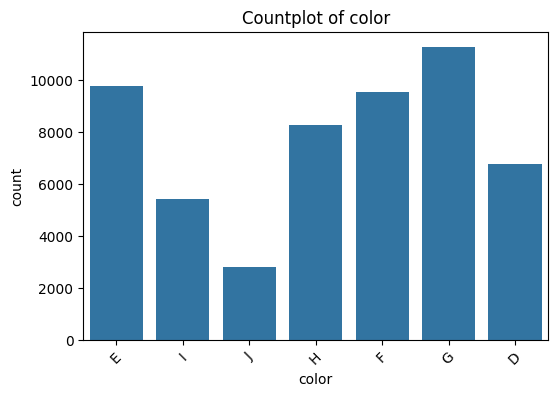

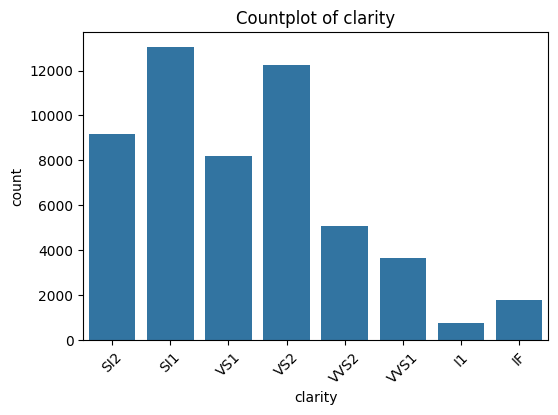

In [ ]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
  plt.figure(figsize=(6,4))
  sns.countplot(x=df[col])
  plt.title(f"Countplot of {col}")
  plt.xticks(rotation=45)
  plt.show()

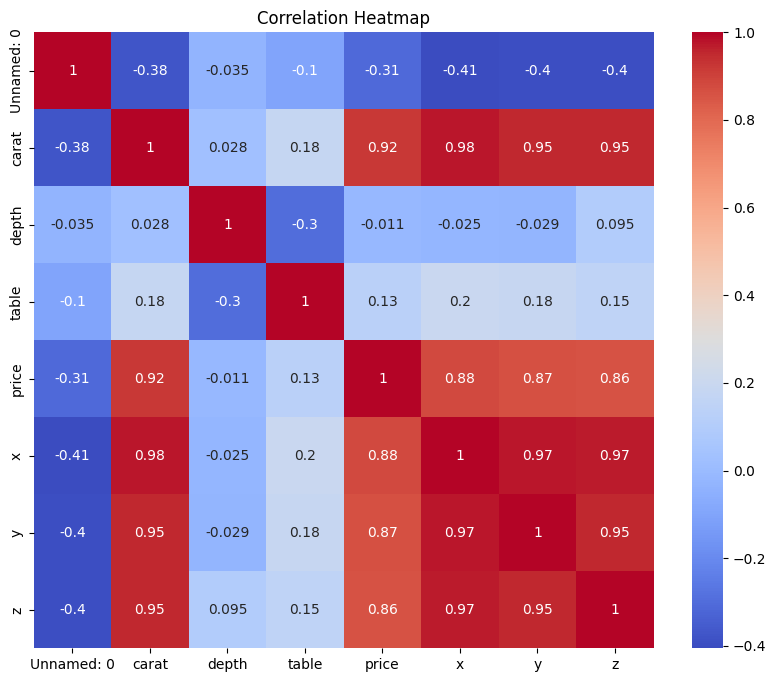

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# step: 6 Model Buliding

In [ ]:
categorical_cols = ["cut","color","clarity"]
numerical_cols = ["carat","depth","table","x","y","z"]
preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numerical_cols),
        ("cat",OneHotEncoder(drop="first"),categorical_cols)
    ]
)
lr_pipeline = Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("reg",LinearRegression())
    ]
)
ridge_pipeline = Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("reg",Ridge())
    ]
)
lasso_pipeline = Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("reg",Lasso())
    ]
)
dt_pipeline = Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("reg",DecisionTreeRegressor(random_state=42))
    ]
)
rf_pipeline = Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("reg",RandomForestRegressor(random_state=42))
    ]
)
grid_params = {
    "reg__n_estimators": {
        "algo": lr_pipeline,
        "params": {}
    },
    "Ridge_Regression" : {
        "algo": ridge_pipeline,
        "params": {
            "reg__alpha": [0.001,0.01,0.1,1]
        }
    },
    "Lasso_Regression": {
        "algo": lasso_pipeline,
        "params": {
            "reg__alpha": [0.001,0.01,0.1,1]
        }
    },
    "Decision_Tree": {
        "algo": dt_pipeline,
        "params": {
            "reg__max_depth": [3,5,7,10],
            "reg__min_samples_split": [2,5,10]
        }
    },
    "Random_Forest": {
        "algo": rf_pipeline,
        "params": {
            "reg__n_estimators": [50,100],
            "reg__max_depth": [5,10],
            "reg__min_samples_split": [2,5]
        }
    }
}
results = []
for name, model in grid_params.items():
  reg = GridSearchCV(estimator=model["algo"],param_grid=model["params"],cv=5,scoring="r2",verbose=1,n_jobs=-1)
  reg.fit(X_train,y_train)
  best_model = reg.best_estimator_
  y_pred = best_model.predict(X_test)
  r2 = r2_score(y_test,y_pred)
  mse = mean_squared_error(y_test,y_pred)
  mae = mean_absolute_error(y_test,y_pred)
  rmse = np.sqrt(mse)
  results.append({
      "Model_Name": name,
      "Best_params": reg.best_params_,
      "r2" : r2,
      "mse": mse,
      "mae": mae,
      "rmse": rmse
  })
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="r2",ascending=False)
print(results_df)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
          Model_Name                                        Best_params  \
4      Random_Forest  {'reg__max_depth': 10, 'reg__min_samples_split...   
3      Decision_Tree  {'reg__max_depth': 10, 'reg__min_samples_split...   
2   Lasso_Regression                                {'reg__alpha': 0.1}   
1   Ridge_Regression                                {'reg__alpha': 0.1}   
0  reg__n_estimators                                                 {}   

         r2           mse         mae         rmse  
4  0.960298  6.311386e+05  399.687992   794.442328  
3  0.950119  7.929451e+05  449.499457   890.474655  
2  0.918943  1.288549e+06  736.583435  1135.142720  
1  0.918934  1.288697e+06  737.105689